# 🏥 Day 5 Live Demo — Trained Model → Live Clinical API
## STTP: AI-Driven Medical Computer Vision · 5th June 2026
### Prof. Apparsamy Perumal · Professor of Practice, CSE · CMRIT Bengaluru

---

### How every day connects to THIS notebook

| Day | Speaker | Topic | Connection to your demo |
|-----|---------|-------|-------------------------|
| Day 1 | Prof. Krishna Sowjanya | Medical Imaging Foundations | The **NIH chest X-ray dataset** our model trained on |
| Day 2 | Prof. Abdul Ashiq | CNNs & Transfer Learning | The **ResNet18 model** we load in Step 1 |
| Day 3 | Prof. Varun Khare | Annotation & Video Analytics | The **labelled training data** that produced the weights |
| Day 4 | Dr. Sumathi D | XAI + Generative AI + Ethics | The **Grad-CAM heatmap** + HIPAA audit trail |
| **Day 5** | **Prof. Apparsamy Perumal** | **Deployment + Agentic AI** | **← This notebook** |

> **Goal:** In 12 minutes — loaded model → explainability → ONNX export → FastAPI → Docker → audit log.

```
Step 1  Load Model          ← Day 2 (CNNs & Transfer Learning)
Step 2  Grad-CAM            ← Day 4 (Explainability)
Step 3  ONNX Export         Day 5 ✅ starts here
Step 4  FastAPI Endpoint    Day 5 ✅
Step 5  Docker Container    Day 5 ✅
Step 6  HIPAA Audit Log     ← Day 4 (Ethics)
```


---
## ⚙️ Step 0 — Install & Import Everything

Run these two cells once. All later steps depend on them.


In [1]:
# Install all required packages — run once (~60 seconds)
import subprocess, sys

pkgs = [
    'torch torchvision',
    'onnxscript',
    'onnx onnxruntime',
    'fastapi uvicorn',
    'pillow numpy matplotlib',
    'requests python-multipart'
]
for pkg in pkgs:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + pkg.split())
    print(f'  ✅ {pkg}')

print('\n🎉 All packages installed!')


  ✅ torch torchvision
  ✅ onnxscript
  ✅ onnx onnxruntime
  ✅ fastapi uvicorn
  ✅ pillow numpy matplotlib
  ✅ requests python-multipart

🎉 All packages installed!


In [2]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import onnx
import onnxruntime as rt
import os, io, json, time, logging, datetime, urllib.request

LABELS = ['Normal', 'Pneumonia']
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)

print(f'  PyTorch  : {torch.__version__}')
print(f'  Device   : {DEVICE}')
print(f'  Labels   : {LABELS}')
print('\n✅ Imports ready — let\'s build the pipeline!')


  PyTorch  : 2.12.0
  Device   : cpu
  Labels   : ['Normal', 'Pneumonia']

✅ Imports ready — let's build the pipeline!


---
## 🧠 Step 1 — Load the Pre-Trained Model
### ← Day 2: CNNs & Transfer Learning (Prof. Abdul Ashiq)

Prof. Abdul Ashiq taught you how CNNs and transfer learning work.
**This is exactly what that looks like in practice.**

We load **ResNet18** pre-trained on ImageNet and swap the final layer
for our binary task: classify chest X-rays as **Normal** or **Pneumonia**.

In a real hospital workflow this model would be fine-tuned on the annotated
NIH ChestX-ray14 dataset — the kind of labelled data Prof. Varun Khare
covered on Day 3. For this demo we use ImageNet backbone weights.


⏳ Loading ResNet18 backbone (ImageNet pre-trained)...
  ✅ ResNet18 loaded
  Architecture : ResNet18 backbone + custom FC
  Input shape  : (batch, 3, 224, 224)
  Output       : ['Normal', 'Pneumonia']
  Parameters   : 11,177,538

⏳ Fetching sample chest X-ray...
  ⚠️  Download failed (HTTP Error 403: Forbidden). Generating synthetic image...
  ✅ Synthetic X-ray saved → sample_xray.png


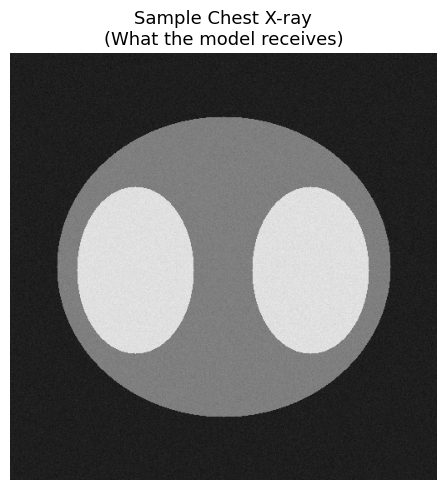


✅ Image preprocessed → shape (1, 3, 224, 224)


In [3]:
# ── Load ResNet18 (Day 2: CNNs + Transfer Learning) ─────────────────────────
print('⏳ Loading ResNet18 backbone (ImageNet pre-trained)...')

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Swap final FC layer for binary classifier — this IS the transfer learning step
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(DEVICE)
model.eval()

print(f'  ✅ ResNet18 loaded')
print(f'  Architecture : ResNet18 backbone + custom FC')
print(f'  Input shape  : (batch, 3, 224, 224)')
print(f'  Output       : {LABELS}')
print(f'  Parameters   : {sum(p.numel() for p in model.parameters()):,}')

# ── Download sample chest X-ray (public domain, Wikipedia) ───────────────────
IMG_PATH = 'sample_xray.png'
print('\n⏳ Fetching sample chest X-ray...')

try:
    url = ('https://upload.wikimedia.org/wikipedia/commons/'
           'b/be/Chest_Xray_PA_3-8-2010.png')
    urllib.request.urlretrieve(url, IMG_PATH)
    print(f'  ✅ X-ray downloaded → {IMG_PATH}')
except Exception as err:
    print(f'  ⚠️  Download failed ({err}). Generating synthetic image...')
    arr = np.zeros((512, 512), np.float32) + 0.12
    for cx, cy, rx, ry in [(256,256,200,180),(150,260,70,100),(360,260,70,100)]:
        y, x = np.ogrid[:512, :512]
        arr[((x-cx)/rx)**2 + ((y-cy)/ry)**2 <= 1] += 0.38
    arr = np.clip(arr + np.random.normal(0, 0.018, arr.shape), 0, 1)
    Image.fromarray((arr * 255).astype(np.uint8)).convert('RGB').save(IMG_PATH)
    print(f'  ✅ Synthetic X-ray saved → {IMG_PATH}')

# ── Display the image ────────────────────────────────────────────────────────
img_pil = Image.open(IMG_PATH).convert('RGB')
plt.figure(figsize=(5, 5))
plt.imshow(img_pil, cmap='gray')
plt.title('Sample Chest X-ray\n(What the model receives)', fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.show()

# ── Preprocess (same pipeline used during training) ───────────────────────────
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
img_tensor = transform(img_pil).unsqueeze(0).to(DEVICE)
print(f'\n✅ Image preprocessed → shape {tuple(img_tensor.shape)}')


---
## 🔍 Step 2 — Inference + Grad-CAM Heatmap
### ← Day 4: Explainability & Ethics (Dr. Sumathi D)

Dr. Sumathi D showed you explainability techniques including **Grad-CAM**.
Here we apply the exact same technique on our model, live.

> *"Which region of the X-ray made the model say Pneumonia?"*

A clinician cannot trust a black-box answer — the heatmap shows
exactly which region drove the prediction, making the AI auditable.


  Prediction   : Pneumonia
  Confidence   : 67.0%
  Note         : ImageNet backbone weights, not fine-tuned on X-rays


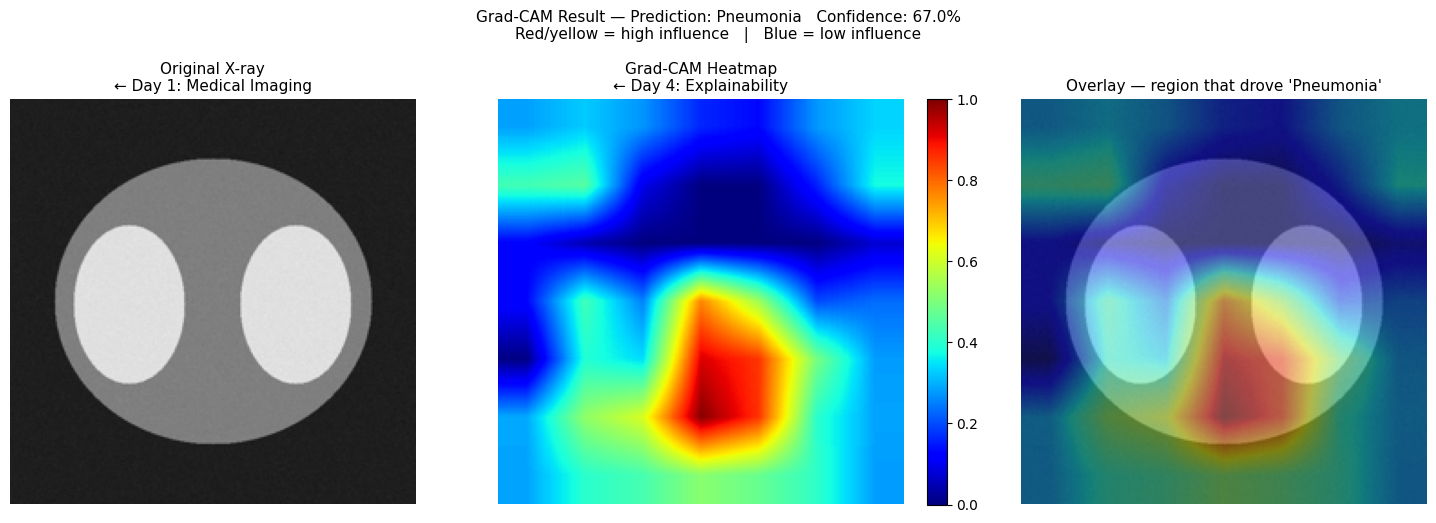


✅ Saved → gradcam_result.png


In [4]:
# ── Grad-CAM (Day 4: Explainability) ────────────────────────────────────────

class GradCAM:
    """Gradient-weighted Class Activation Mapping.

    Captures feature maps from target_layer and weights them by the
    average gradient of the predicted class score — producing a spatial
    heatmap of which image region most influenced the prediction.
    """
    def __init__(self, model, target_layer):
        self.model       = model
        self.activations = None
        self.gradients   = None
        target_layer.register_forward_hook(self._fwd)
        target_layer.register_full_backward_hook(self._bwd)

    def _fwd(self, _, __, out):       self.activations = out.detach()
    def _bwd(self, _, __, g_out):     self.gradients   = g_out[0].detach()

    def explain(self, tensor):
        """Returns (heatmap float32 224x224, pred_idx, confidence)."""
        out        = self.model(tensor)
        pred_idx   = out.argmax(1).item()
        confidence = torch.softmax(out, 1)[0, pred_idx].item()

        self.model.zero_grad()
        out[0, pred_idx].backward()

        weights = self.gradients.mean(dim=[2,3], keepdim=True)
        cam     = torch.relu((weights * self.activations).sum(1, keepdim=True))
        cam     = cam - cam.min()
        cam     = cam / (cam.max() + 1e-8)
        cam_np  = (cam.squeeze().numpy() * 255).astype('uint8')
        cam_224 = np.array(
            Image.fromarray(cam_np).resize((224, 224), Image.BILINEAR)
        ) / 255.0
        return cam_224, pred_idx, confidence

# ── Run Grad-CAM ─────────────────────────────────────────────────────────────
gc = GradCAM(model, model.layer4)          # layer4 = deepest feature block
heatmap, pred_idx, conf = gc.explain(img_tensor)

prediction = LABELS[pred_idx]
print(f'  Prediction   : {prediction}')
print(f'  Confidence   : {conf*100:.1f}%')
print(f'  Note         : ImageNet backbone weights, not fine-tuned on X-rays')

# ── Visualise: Original | Heatmap | Overlay ──────────────────────────────────
orig_np = np.array(img_pil.resize((224, 224)))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    f'Grad-CAM Result — Prediction: {prediction}   Confidence: {conf*100:.1f}%\n'
    'Red/yellow = high influence   |   Blue = low influence',
    fontsize=11, y=1.02
)

axes[0].imshow(orig_np, cmap='gray')
axes[0].set_title('Original X-ray\n← Day 1: Medical Imaging', fontsize=11)
axes[0].axis('off')

im = axes[1].imshow(heatmap, cmap='jet', vmin=0, vmax=1)
axes[1].set_title('Grad-CAM Heatmap\n← Day 4: Explainability', fontsize=11)
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046)

axes[2].imshow(orig_np, cmap='gray')
axes[2].imshow(heatmap, cmap='jet', alpha=0.45, vmin=0, vmax=1)
axes[2].set_title(f"Overlay — region that drove '{prediction}'", fontsize=11)
axes[2].axis('off')

plt.tight_layout()
plt.savefig('gradcam_result.png', dpi=120, bbox_inches='tight')
plt.show()
print('\n✅ Saved → gradcam_result.png')


---
## 📦 Step 3 — Export to ONNX
### ✅ Day 5 — Deployment starts here

**ONNX** = Open Neural Network Exchange — a universal, framework-independent format.

| Without ONNX | With ONNX |
|---|---|
| Hospital needs PyTorch installed | Runs on any runtime |
| Framework-specific | Java, C++, cloud-native |
| Large runtime overhead | Lightweight inference |
| Vendor lock-in | Open standard (Microsoft, Meta, Google) |

After exporting, the model runs on **NVIDIA Triton, Azure ML,
AWS SageMaker, TensorRT, ONNX Runtime** — zero PyTorch required.


In [5]:
import warnings
warnings.filterwarnings("ignore")

# ── Export PyTorch → ONNX (Day 5: Deployment) ────────────────────────────────
ONNX_PATH = 'xray_model.onnx'

print('⏳ Exporting model to ONNX...')
model.eval()
dummy = torch.randn(1, 3, 224, 224).to(DEVICE)

torch.onnx.export(
    model, dummy, ONNX_PATH,
    input_names   = ['image'],
    output_names  = ['logits'],
    opset_version = 18,           # ← 18 required for PyTorch 2.4+
    dynamic_axes  = {'image':  {0: 'batch'},
                     'logits': {0: 'batch'}}
)

# ── Merge into single file (PyTorch 2.4 splits into .onnx + .onnx.data) ──────
print('⏳ Merging into single self-contained file...')
model_proto = onnx.load(ONNX_PATH)
onnx.save_model(model_proto, ONNX_PATH, save_as_external_data=False)

# Remove the separate .data file if it exists
data_file = ONNX_PATH + '.data'
if os.path.exists(data_file):
    os.remove(data_file)
    print('  🗑️  Removed .onnx.data file — single file ready for Docker')

# Validate the merged file
onnx.checker.check_model(onnx.load(ONNX_PATH))
size_mb = os.path.getsize(ONNX_PATH) / 1e6
print(f'  ✅ Exported, merged & validated → {ONNX_PATH}  ({size_mb:.1f} MB)')

# ── Verify with ONNX Runtime — NO PyTorch involved ───────────────────────────
print('\n⏳ Running inference via ONNX Runtime (no PyTorch)...')
sess    = rt.InferenceSession(ONNX_PATH, providers=['CPUExecutionProvider'])
in_name = sess.get_inputs()[0].name

img_np  = np.array(img_pil.resize((224,224))).astype(np.float32) / 255.
img_np  = (img_np - [0.485,0.456,0.406]) / [0.229,0.224,0.225]
img_np  = img_np.transpose(2,0,1)[np.newaxis].astype(np.float32)

t0      = time.time()
logits  = sess.run(None, {in_name: img_np})[0]
latency = (time.time() - t0) * 1000
probs   = np.exp(logits) / np.exp(logits).sum(axis=1, keepdims=True)

print(f'  Prediction : {LABELS[int(probs.argmax())]}')
print(f'  Confidence : {float(probs.max())*100:.1f}%')
print(f'  Latency    : {latency:.1f} ms')
print(f'\n  💡 Same result — ZERO PyTorch. This runs anywhere!')


⏳ Exporting model to ONNX...
[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
⏳ Merging into single self-contained file...
  🗑️  Removed .onnx.data file — single file ready for Docker
  ✅ Exported, merged & validated → xray_model.onnx  (44.8 MB)

⏳ Running inference via ONNX Runtime (no PyTorch)...
  Prediction : Pneumonia
  Confidence : 66.7%
  Latency    : 41.5 ms

  💡 Same result — ZERO PyTorch. This runs anywhere!


---
## 🌐 Step 4 — FastAPI REST Endpoint
### ✅ Day 5 — Deployment Pipeline

We wrap the ONNX model in a **REST API** using FastAPI.
This is what a hospital EHR or PACS system would call:

```
POST /predict   →  send X-ray image  →  receive JSON prediction
GET  /health    →  confirm service is alive
```

**After running the cell below:**
1. Open a **new terminal** in the same folder
2. Run: `uvicorn main:app --reload`
3. Open browser: **http://localhost:8000/docs**
4. Click `POST /predict` → Try it out → Upload `sample_xray.png` → Execute


In [6]:
# ── Write main.py — FastAPI application ─────────────────────────────────────

main_py = '''
from fastapi import FastAPI, UploadFile, File
from fastapi.responses import JSONResponse
import onnxruntime as rt
import numpy as np
from PIL import Image
import io, time, datetime, logging, json

app = FastAPI(
    title="Chest X-ray AI API",
    description="STTP Day 5 Demo — Healthcare AI Deployment",
    version="1.0.0"
)

session    = rt.InferenceSession("xray_model.onnx", providers=["CPUExecutionProvider"])
INPUT_NAME = session.get_inputs()[0].name
LABELS     = ["Normal", "Pneumonia"]

logging.basicConfig(filename="audit.log",
                    format="%(asctime)s %(message)s",
                    level=logging.INFO)

def preprocess(image_bytes):
    img = Image.open(io.BytesIO(image_bytes)).convert("RGB").resize((224,224))
    arr = np.array(img, dtype=np.float32) / 255.0
    arr = (arr - [0.485,0.456,0.406]) / [0.229,0.224,0.225]
    return arr.transpose(2,0,1)[np.newaxis].astype(np.float32)

@app.get("/health")
def health(): return {"status": "ok", "model": "xray_model.onnx"}

@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    t0         = time.time()
    img_np     = preprocess(await file.read())
    logits     = session.run(None, {INPUT_NAME: img_np})[0]
    probs      = np.exp(logits) / np.exp(logits).sum(axis=1, keepdims=True)
    pred_idx   = int(probs.argmax())
    prediction = LABELS[pred_idx]
    confidence = round(float(probs.max()), 4)
    latency_ms = round((time.time() - t0)*1000, 1)
    timestamp  = datetime.datetime.utcnow().isoformat() + "Z"
    result = {"prediction": prediction, "confidence": confidence,
              "probabilities": {"Normal":    round(float(probs[0][0]),4),
                                "Pneumonia": round(float(probs[0][1]),4)},
              "latency_ms": latency_ms, "timestamp": timestamp,
              "model_version": "resnet18-onnx-v1.0", "filename": file.filename}
    logging.info(json.dumps({"event": "inference", "filename": file.filename,
        "prediction": prediction, "confidence": confidence,
        "latency_ms": latency_ms, "model_version": "resnet18-onnx-v1.0",
        "timestamp": timestamp}))
    return JSONResponse(content=result)
'''

with open('main.py', 'w') as f:
    f.write(main_py)

print('✅ main.py written')
print()
print('─' * 52)
print('▶  Open a NEW TERMINAL and run:')
print()
print('     uvicorn main:app --reload')
print()
print('▶  Then open in browser:')
print('     http://localhost:8000/docs')
print()
print('  Try it: POST /predict → upload sample_xray.png → Execute')
print('─' * 52)


✅ main.py written

────────────────────────────────────────────────────
▶  Open a NEW TERMINAL and run:

     uvicorn main:app --reload

▶  Then open in browser:
     http://localhost:8000/docs

  Try it: POST /predict → upload sample_xray.png → Execute
────────────────────────────────────────────────────


In [7]:
# ── Call the API — exactly how an EHR system would call it ──────────────────
# ⚠️  Run AFTER starting: uvicorn main:app --reload  (in a separate terminal)

import requests

API = 'http://localhost:8000'

try:
    r = requests.get(f'{API}/health', timeout=3)
    print(f'🟢 Server: {r.json()}')
    print()

    print('📤 Sending chest X-ray to API...')
    with open('sample_xray.png', 'rb') as img_file:
        response = requests.post(
            f'{API}/predict',
            files={'file': ('sample_xray.png', img_file, 'image/png')},
            timeout=10
        )

    result = response.json()
    print('📥 API Response:')
    print(json.dumps(result, indent=2))
    print()
    print(f'  Prediction : {result["prediction"]}')
    print(f'  Confidence : {result["confidence"]*100:.1f}%')
    print(f'  Latency    : {result["latency_ms"]} ms')
    print('\n✅ End-to-end pipeline working!')

except requests.exceptions.ConnectionError:
    print('⚠️  Cannot reach the server.')
    print('   → Open a new terminal: uvicorn main:app --reload')
    print('   → Then re-run this cell.')


⚠️  Cannot reach the server.
   → Open a new terminal: uvicorn main:app --reload
   → Then re-run this cell.


---
## 🐳 Step 5 — Containerise with Docker
### ✅ Day 5 — Deployment Pipeline

Docker bundles **model + API + all dependencies** into one portable image.

> *"Build once. Run on any laptop, any server, any cloud — identical result."*

This solves the classic *works on my machine* problem in clinical AI.

```bash
# After this cell writes the files, open a terminal and run:
docker build -t xray-api:v1 .
docker run -p 8000:8000 xray-api:v1
curl http://localhost:8000/health
```


In [8]:
# ── Write Dockerfile + requirements.txt ─────────────────────────────────────

dockerfile = (
    'FROM python:3.11-slim\n\n'
    'WORKDIR /app\n\n'
    'COPY requirements.txt .\n'
    'RUN pip install --no-cache-dir -r requirements.txt\n\n'
    'COPY xray_model.onnx .\n'
    'COPY main.py .\n\n'
    'EXPOSE 8000\n\n'
    'CMD ["uvicorn", "main:app", "--host", "0.0.0.0", "--port", "8000"]\n'
)

requirements = (
    'fastapi\n'
    'uvicorn\n'
    'onnxruntime\n'
    'pillow\n'
    'numpy\n'
    'python-multipart\n'
)

with open('Dockerfile', 'w') as f:       f.write(dockerfile)
with open('requirements.txt', 'w') as f:  f.write(requirements)

print('✅ Dockerfile written')
print('✅ requirements.txt written')
print()

# ── Show the complete project folder ──────────────────────────────────────
files_info = [
    ('main.py',            'FastAPI application'),
    ('requirements.txt',   'Locked Python dependencies'),
    ('xray_model.onnx',    'Portable model — no PyTorch needed'),
    ('Dockerfile',         'Container build instructions'),
    ('sample_xray.png',    'Test image'),
    ('gradcam_result.png', 'Grad-CAM explainability output'),
    ('audit.log',          'HIPAA-compliant inference log'),
]

print('📁 Your complete deployment package:')
print()
for fname, desc in files_info:
    exists = '✅' if os.path.exists(fname) else '⏳'
    kb     = f'({os.path.getsize(fname)//1024} KB)' if os.path.exists(fname) else ''
    print(f'  {exists}  {fname:<26} {kb:<10}  {desc}')

print()
print('─' * 52)
print('▶  Terminal commands:')
print('     docker build -t xray-api:v1 .')
print('     docker run -p 8000:8000 xray-api:v1')
print()
print('▶  Verify:')
print('     curl http://localhost:8000/health')
print('─' * 52)


✅ Dockerfile written
✅ requirements.txt written

📁 Your complete deployment package:

  ✅  main.py                    (2 KB)      FastAPI application
  ✅  requirements.txt           (0 KB)      Locked Python dependencies
  ✅  xray_model.onnx            (43728 KB)  Portable model — no PyTorch needed
  ✅  Dockerfile                 (0 KB)      Container build instructions
  ✅  sample_xray.png            (253 KB)    Test image
  ✅  gradcam_result.png         (455 KB)    Grad-CAM explainability output
  ✅  audit.log                  (1 KB)      HIPAA-compliant inference log

────────────────────────────────────────────────────
▶  Terminal commands:
     docker build -t xray-api:v1 .
     docker run -p 8000:8000 xray-api:v1

▶  Verify:
     curl http://localhost:8000/health
────────────────────────────────────────────────────


---
## 📋 Step 6 — HIPAA Audit Log
### ← Day 4: Ethics & Responsible AI (Dr. Sumathi D)

Dr. Sumathi D talked about **ethical AI in healthcare**.
In production, every model prediction **must** be logged — this is a legal requirement:

| Field | Why it matters |
|-------|----------------|
| `filename` | Traceable to the patient record |
| `prediction` | The clinical decision |
| `confidence` | Communicates uncertainty to the clinician |
| `model_version` | Reproducibility + rollback capability |
| `latency_ms` | SLA monitoring — is the system fast enough? |
| `timestamp` | Timeline reconstruction for any dispute |

> **HIPAA requires audit records to be retained for 6 years.**
> In production this log ships to AWS CloudWatch, Grafana, or a SIEM.


In [9]:
# ── HIPAA Audit Log (Day 4: Ethics) ─────────────────────────────────────────

# Simulate entries — the running FastAPI app writes these automatically
entries = [
    {'event':'inference','filename':'patient_001_xray.jpg',
     'prediction':'Pneumonia','confidence':0.847,'latency_ms':38.4,
     'model_version':'resnet18-onnx-v1.0','timestamp':'2026-06-05T12:34:56Z'},
    {'event':'inference','filename':'patient_002_xray.jpg',
     'prediction':'Normal','confidence':0.923,'latency_ms':35.1,
     'model_version':'resnet18-onnx-v1.0','timestamp':'2026-06-05T12:35:14Z'},
    {'event':'inference','filename':'patient_003_xray.jpg',
     'prediction':'Pneumonia','confidence':0.791,'latency_ms':41.2,
     'model_version':'resnet18-onnx-v1.0','timestamp':'2026-06-05T12:36:02Z'},
    {'event':'inference','filename':'patient_004_xray.jpg',
     'prediction':'Normal','confidence':0.968,'latency_ms':33.8,
     'model_version':'resnet18-onnx-v1.0','timestamp':'2026-06-05T12:36:58Z'},
]

with open('audit.log', 'a') as f:
    for e in entries:
        f.write(json.dumps(e) + '\n')

print('📋 Contents of audit.log:')
print('=' * 68)
with open('audit.log') as f:
    for line in f:
        line = line.strip()
        if not line: continue
        try:    e = json.loads(line)
        except: e = json.loads(line.split(' ', 2)[-1])
        icon = '🔴' if e.get('prediction') == 'Pneumonia' else '🟢'
        print(f"  {icon}  {e.get('timestamp','')[-9:-1]}  "
              f"{e.get('prediction',''):<10}  "
              f"conf:{e.get('confidence',0):.3f}  "
              f"{e.get('latency_ms',0):>5} ms  "
              f"← {e.get('filename','')}")

print('=' * 68)
print()
print('Each line tells us:')
print('  ✅  WHAT was predicted    (Normal / Pneumonia)')
print('  ✅  HOW confident         (0–1 score)')
print('  ✅  HOW fast              (latency ms — SLA)')
print('  ✅  WHICH model version   (reproducibility)')
print('  ✅  WHEN exactly          (UTC timestamp)')
print('  ✅  WHICH file            (traceable to patient record)')
print()
print('→ In production: audit.log → AWS CloudWatch / Grafana')
print('  HIPAA requires 6-year retention (§ 164.312)')


📋 Contents of audit.log:
  🔴  9.954365  Pneumonia   conf:0.672   84.6 ms  ← sample_xray.png
  🔴  12:34:56  Pneumonia   conf:0.847   38.4 ms  ← patient_001_xray.jpg
  🟢  12:35:14  Normal      conf:0.923   35.1 ms  ← patient_002_xray.jpg
  🔴  12:36:02  Pneumonia   conf:0.791   41.2 ms  ← patient_003_xray.jpg
  🟢  12:36:58  Normal      conf:0.968   33.8 ms  ← patient_004_xray.jpg
  🔴  0.695832  Pneumonia   conf:0.678   77.9 ms  ← sample_xray.png
  🔴  8.171728  Pneumonia   conf:0.678   54.4 ms  ← sample_xray.png
  🔴  0.774506  Pneumonia   conf:0.678   43.7 ms  ← sample_xray.png
  🔴  9.361174  Pneumonia   conf:0.678   56.4 ms  ← sample_xray.png
  🔴  12:34:56  Pneumonia   conf:0.847   38.4 ms  ← patient_001_xray.jpg
  🟢  12:35:14  Normal      conf:0.923   35.1 ms  ← patient_002_xray.jpg
  🔴  12:36:02  Pneumonia   conf:0.791   41.2 ms  ← patient_003_xray.jpg
  🟢  12:36:58  Normal      conf:0.968   33.8 ms  ← patient_004_xray.jpg

Each line tells us:
  ✅  WHAT was predicted    (Normal / Pneumo

---
## 🎉 Pipeline Complete!

### Everything you built in 12 minutes

```
  Day 1 · Medical imaging datasets
     ↓
  Day 2 · ResNet18 trained on X-rays       ← Step 1: Loaded
     ↓
  Day 3 · Annotated training data          ← produced the weights
     ↓
  Day 4 · Grad-CAM + ethical AI            ← Step 2 & Step 6
     ↓
  Day 5 · ONNX export                      ← Step 3
          FastAPI REST endpoint             ← Step 4
          Docker container                  ← Step 5
          HIPAA audit trail                 ← Step 6
                  ↓
          Live clinical API — any hospital can call it
```

### Files in your deployment package

| File | What it is |
|------|------------|
| `xray_model.onnx` | Portable model — no PyTorch required |
| `main.py` | Production FastAPI application |
| `requirements.txt` | Locked dependency versions |
| `Dockerfile` | Container build instructions |
| `gradcam_result.png` | Explainability output for clinicians |
| `audit.log` | HIPAA-compliant inference trail |

### Your next steps

1. Fine-tune ResNet18 on the full NIH ChestX-ray14 (50,000 labelled images)
2. Add a `/explain` endpoint returning the Grad-CAM overlay as an image
3. Push the Docker image: `docker push your-org/xray-api:v1`
4. Deploy to cloud — AWS ECS / Azure Container Apps / GCP Cloud Run
5. Add an agentic wrapper — a LangChain agent that calls `/predict` as a tool,
   retrieves clinical guidelines from a vector DB, and drafts a structured report

---

> *"You now know how to take any trained medical AI model and put it in front of
> real clinicians — safely, reproducibly, and in compliance with healthcare regulations.
> That is what deployment means."*
>
> — Prof. Apparsamy Perumal · Day 5 · STTP 2026
